In [1]:
import uproot as up
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = '/uscms/home/wkarunar/nobackup/datasets/data/run3/ZeroBias/crab_TTree_136TeV_ZeroBias_mm_2023C_v4.root'
tree = up.open(file_path)["ntuple"]
cols_to_read = ['Event', 'Run', 'LumiBlock', 'savedtriggerNames', 'savedtriggerBits']
cut = "(LumiBlock >= 800) & (LumiBlock < 850)"
# cut = "(LumiBlock >= 0) & (LumiBlock < 10000)"

In [3]:
# number of events to read
tree.num_entries

0

In [4]:
trigger_firing_count_df_array = []

In [5]:
def process_chunk(array):
    df = pd.DataFrame({col: array[col] for col in cols_to_read})

    # Check if the DataFrame is empty
    if df.empty:
        print("DataFrame is empty.")
        return None

    # Convert to integers/floats as needed
    df['Event'] = df['Event'].astype(int)
    df['Run'] = df['Run'].astype(int)
    df['LumiBlock'] = df['LumiBlock'].astype(int)

    if all(df['savedtriggerNames'].apply(lambda x: all(x == df['savedtriggerNames'].iloc[0]))):
        # print("All trigger names are the same.")
        triggerNames = df['savedtriggerNames'].iloc[0]
    else:
        # throw an error
        raise ValueError("Trigger names differ across events.")

    trigger_bits_df = df['savedtriggerBits'].apply(pd.Series)
    trigger_bits_df.columns = triggerNames
    # final_df = pd.concat([df[['Event', 'Run', 'LumiBlock']], trigger_bits_df], axis=1)

    trigger_firing_count = trigger_bits_df.sum()
    trigger_firing_count_df = trigger_firing_count.to_frame(name="FiringCount").sort_values(by="FiringCount", ascending=False)

    trigger_firing_count_df.reset_index(inplace=True)
    trigger_firing_count_df.columns = ['TriggerName', 'FiringCount']

    # clear unused memory
    del df
    del trigger_bits_df
    
    return trigger_firing_count_df

In [6]:
for i, array in enumerate(tree.iterate(cols_to_read, step_size=10000, library='np', cut=cut)):
    print(f"Processing chunk {i}")
    trigger_firing_count_df = process_chunk(array)
    trigger_firing_count_df_array.append(trigger_firing_count_df)
    # if i>2:
    #     break
    # if trigger_firing_count_df is not None:
    #     break

Processing chunk 0
DataFrame is empty.
Processing chunk 1
DataFrame is empty.
Processing chunk 2
Processing chunk 3
Processing chunk 4
DataFrame is empty.
Processing chunk 5
DataFrame is empty.
Processing chunk 6
Processing chunk 7
Processing chunk 8
Processing chunk 9
DataFrame is empty.
Processing chunk 10
DataFrame is empty.
Processing chunk 11
DataFrame is empty.
Processing chunk 12
Processing chunk 13
DataFrame is empty.
Processing chunk 14
DataFrame is empty.
Processing chunk 15
Processing chunk 16
DataFrame is empty.
Processing chunk 17
DataFrame is empty.
Processing chunk 18
DataFrame is empty.
Processing chunk 19
DataFrame is empty.
Processing chunk 20
Processing chunk 21
Processing chunk 22
DataFrame is empty.
Processing chunk 23
DataFrame is empty.
Processing chunk 24
DataFrame is empty.
Processing chunk 25
DataFrame is empty.
Processing chunk 26
DataFrame is empty.
Processing chunk 27
Processing chunk 28
DataFrame is empty.
Processing chunk 29
DataFrame is empty.
Processing

In [7]:
# concatenate all dataframes
df = pd.concat(trigger_firing_count_df_array, ignore_index=True)
df = df.groupby('TriggerName').sum().reset_index()
df = df.sort_values(by="FiringCount", ascending=False)
df.to_csv('trigger_firing_count_Muon0.csv', index=False)

In [8]:
read_df = pd.read_csv('trigger_firing_count_Muon0.csv')
read_df = read_df.head(15)
read_df

,TriggerName,FiringCount
0,Status_OnGPU,9399
1,Dataset_ScoutingPFRun3,9399
2,Dataset_Muon0,9399
3,DST_HLTMuon_Run3_PFScoutingPixelTracking_v20,9399
4,HLT_Mu0_L1DoubleMu_v5,7981
5,HLT_DoubleMu4_3_LowMass_v5,6702
6,DST_Run3_DoubleMu3_PFScoutingPixelTracking_v20,5901
7,Dataset_ReservedDoubleMuonLowMass,4984
8,HLT_L3Mu10NoVtx_v4,3911
9,HLT_L2Mu10NoVtx_2Cha_v3,3865


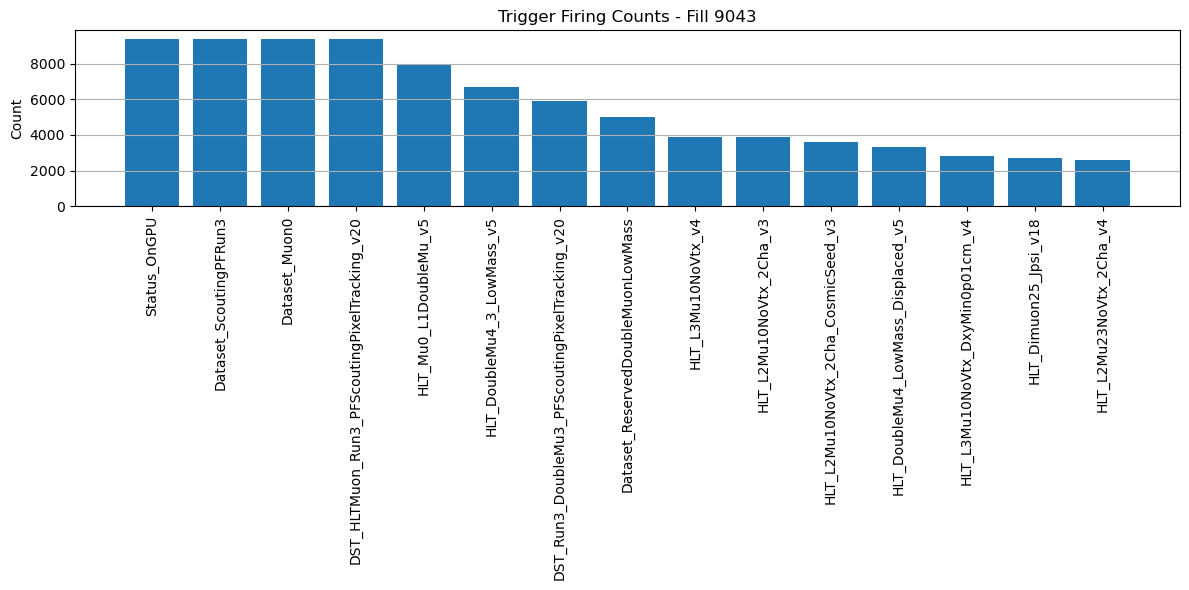

In [9]:
# Plotting the trigger firing counts
plt.figure(figsize=(12, 6))
plt.bar(read_df['TriggerName'], read_df['FiringCount'])
plt.xticks(rotation=90)
plt.ylabel('Count')
plt.title('Trigger Firing Counts - Fill 9043')
plt.grid(True, which='major', axis='y')
plt.tight_layout()